# Discount ladder

The purpose of this Notebook is to demonstrate the use of Settlement Networks as a viechle to deliver a business solution.
The question is wether it is possible to use the discounting of the invoice amounts without touching the obligations in the existing obligation network.
This would allow for factoring like functionality without involvment of a factor.
Building a network that does a function of a legal entity in the traditional transactional environment.
We use the [Multilateral Settlement Network](docs/Multilateral_Settlement_Network.md) model and notation.

## Overview

### Situation

We have Alice, Bob, and Charlie. They all participate in a network N.
Network N might have many other participants.
Alice owes 100 to N. N owes 80 to Bob and Charlie respectively.
Alice, Bob, and Charlie sees no cycles in their obligations within the network.

Alice has plenty of funds and is looking for a good investment opportunity. She
is able and willing to pay her obligations in advance, but her supplier
in network N would rather wait for the full payment on the due date than
accept discounted early payment. Alice is happy to pay early if she
can get a 1\% discount. Bob and Charlie on the other side would like to
get payment earlier. Bob and Charlie's customers in network N are unwilling or
unable to pay early, even for a discount. Bob is offering 2\% and Charly
3\% to get their payment early.

### Problem

* How can we satisfy Alice, Bob, and Charlie?
* Are their intents to offer discounts enough to construct a settlement network with new settlement flows?

### Solution

* Introduce a discounting node to connect the discounting intents of the parties involved.
* Settle for the underlying asset at discount after the flows trough the discounting node are determined.

## Preparing the environment

### Input data

The data describing this situation among Alice, Bob and Charlie in more detail is available [here](data/discount_ladder.csv)

### Import the functions for modeling

We import the functions required to model the settlement networks.

In [11]:
from utils.graph_operations import *
from utils.graph_visualization import graph_print, graph_draw
from utils.graph_max_flow_solvers import max_flow_solver
from utils.graph_read_write import read_graph_from_csv, split_graph_by_edge_data
import networkx as nx

### Reading the network edges data and setting the presentation of data

We start by reading the data and splitting it into two networks: obligations $g$ and commitments $\overline{g}$.
In our case the obligations are among Alice, Bob, Charlie, and the rest of the network N.
The commitments are for the discounted settlement flows.

In [12]:
g = read_graph_from_csv("data/discount_ladder.csv")
g, g_overline = split_graph_by_edge_data(g, "o/c", "o")

# Define the order of rows and columns for later matrix printouts
order = ["alice", "bob", "charlie", "N", "1", "2", "3", "$"]

# Define fixed positions of nodes for network graphs
pos = {'alice': (0,1),
       'bob': (1,1),
       'charlie': (2,1),
       'N': (1,2),
       '1': (0,0),
       '2': (1,0),
       '3': (2,0),
       'DL': (1,0),
       'CB': (3,0),
       '$': (1,2)}

## Visualising the case

### Obligation network

It is obvious from the graph of the obligations network that there is no way for Alice, Bob, and Charlie to reach a settlement.

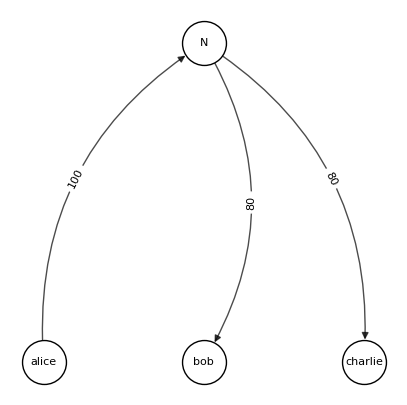

In [13]:
graph_draw(g, pos=pos, connectionstyle="arc3, rad=-0.3", node_size=1000)

### Adding the discounting node to allow for more settlement flows

Adding the discounting node with edges for Alice's, Bob's, and Charlie's intents, new cycles emerge.

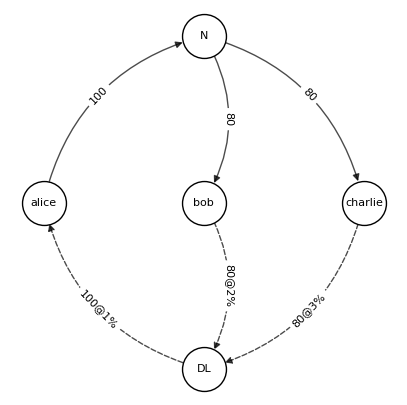

In [14]:
# Temporary discounting network to showcase the new cycles creation.
d = nx.DiGraph()

# Define edges with capacities as a list of tuples
edges = [("DL", "alice", {"capacity": 100, "o/c": 'c'}),
         ("bob", "DL", {"capacity": 80, "o/c": 'c'}),
         ("charlie", "DL", {"capacity": 80, "o/c": 'c'})]

# Add edges with capacities using add_edges_from
d.add_edges_from(edges)

# Join the obligation and the discounting networks
dl = g+d

# Define the labelss for the edges of discounting network.
update_edge_labels = {('DL','alice'): '100@1%',
                      ('bob','DL'): '80@2%',
                      ('charlie','DL'): '80@3%'}

graph_draw(dl, pos=pos, connectionstyle="arc3, rad=-0.3", node_size=1000, update_edge_labels=update_edge_labels)

The issue with the discounting node is that the discounts on the different edges are inconsistent. Because we aim to find a settlement flow using full amounts, we must ensure that the full amounts at higher discounts are not greater than those at lower discounts. This condition can be easily met by constructing a discount ladder.

### Building the discount ladder

We create a node for each discount level and connect the higher discount with the next lower one with an edge of infinite capacity.
This forms a discount ladder that ensures that the settlement flow will be such, that the desired discounts are possible.

Settlement flow is always at full amount. Adding higher discounted flows to lower discount is always possible, but the opposite is not.
The proposed topology will also create a spread on discounts. This will be demonstrated later.

Now we join the obligations and discount networks to form a business case network $p_b$. We use the index b to distinguish the levels.
This is a business level!

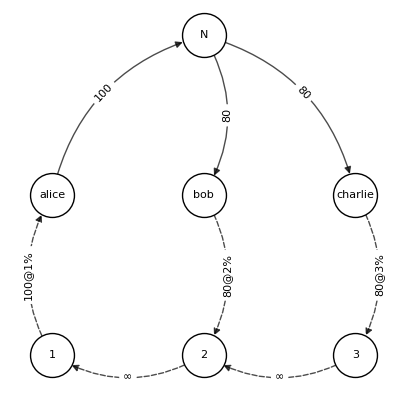

In [15]:
# Join obligations and discount networks
p_b = g+g_overline

# Provide more descriptive labels for the discount network
update_edge_labels = {('1','alice'): '100@1%',
                      ('bob','2'): '80@2%',
                      ('charlie','3'): '80@3%',
                      ('2','1'): '∞',
                      ('3','2'): '∞'}

# graph_draw(p_b, layout_func=nx.planar_layout)
graph_draw(p_b, pos=pos, connectionstyle="arc3, rad=-0.3", node_size=1000, update_edge_labels=update_edge_labels)

### Finding a solution to a business problem

Using a solver, we try to find a solution - cyclic structure $\hat{p_b}$ - within the business network.
The advantage of the proposed solution is that it does not require a specialised solver. Standard MTCS solver does everything that is required.

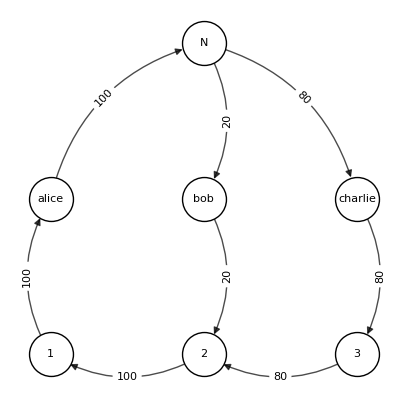

In [16]:
p_b_hat = max_flow_solver(p_b)

graph_draw(p_b_hat, pos=pos, connectionstyle="arc3, rad=-0.3", node_size=1000)

The business flow traverses both, the obligation and the commitment network.
Business flow has to be a cyclic structure. We can see that each node is perfectly balanced, with amounts coming in, and equal amounts coming out.

* Alice is in a good place to get her 1% discount on early payment for her full amount of 100,
* Bob is scheduled for 20 at 2%, and
* Charlie for full amount of 80 at 3%.

Alice receives the full amount due to a higher demand for discounts than her offer.
Bob's 2% offer was outbid by Charlie's 3% discount.

Let's see what remains after we settle the business business flow.

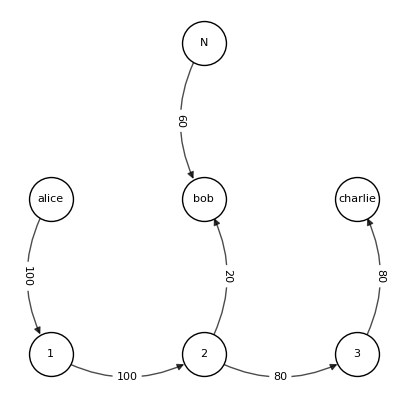

In [17]:
g_b_prime = +(g-p_b_hat) + ~(-(g-p_b_hat))

graph_draw(g_b_prime, pos=pos, connectionstyle="arc3, rad=0.3", node_size=1000)

At this stage Bob is still owed 60 by someone from the network N. Alice and Charlie resolved their obligations with the obliggation network N in full.

What happened is that their commitment to offer and accept discounts
are now translated into a new obligation network with a discount ladder.

Here's one implementation approach: a discount ladder smart contract that holds participants' accounts. To participate with a 1% discount edge offering 100 for 99, Alice would escrow 99 in the smart contract. The contract would then hold all the information required for fund redistribution. Following the discount ladder structure, Bob offering a 2% discount (20 for 19) would receive 19, and Charlie offering a 3% discount (80 for 77) would receive 77.

Notice there is a discrepancy. 19 + 77 < 99 There is 3 left over.

The primary factor causing discrepancies in a discount ladder's distribution is the spread of offered discounts. There is always a leftover amount. It could be a profit for the "owner" of the discount ladder. But, it
would be better used to reward the provision of funds as a cash payback. We
want to incentivize the liquidity provision as much as possible.

One of the potential problems with this solution is that it requires an
escrow implemented in the discount ladder contract. However, with a settlement
network readily available, such escrow could be implemented within the
settlement asset node. That might be advantageous from the regulatory and
users perspective.

So we need to go to the second stage. Settle the business!

## Settlement round

We successfully identified a solution flow for this process, documented in Set-off notices generated by a solver. It's important to note that, as with all value flow models, the settlement flow operates in the opposite direction of the delivery (business) flow. This means we can directly leverage our business flow, represented by $\hat{p_b}$, to construct the settlement network for disbursing funds.

### Setting up the settlement network

Notice that from the perspective of the discount ladder network, the
obligation network N served as a liquidity source for the business
solution. A simple replacement of N for the liquidity source holding
a settlement asset is required to set up the settlement network.

We follow the standard process. First, we create a new settlement network
$g_s$ based on a business solution $\hat{p_b}$. Then we split it into
obligations and commitments - $g_s, \overline{g_s}$ to form a standard
settlement network $p_s$.

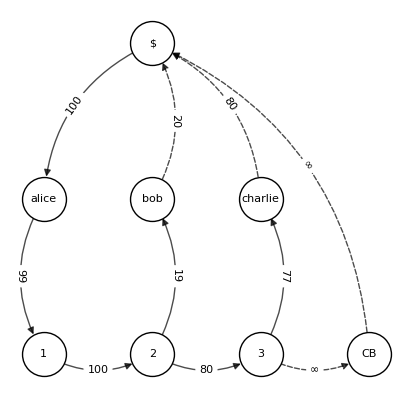

In [18]:
ladder_edges = []
ladder = ["1", "2", "3"]

# Loop trough the set-off notices
for (debtor, creditor, capacity) in p_b_hat.edges(data="capacity"):
    oc = 'o'
    if debtor in ladder and not creditor in ladder: # apply discount for early collection
        capacity -= capacity*(int(debtor)/100)
    elif not debtor in ladder and creditor in ladder: # apply discount for early payment
        capacity -= capacity*(int(creditor)/100)
    # Flow solvers only accept integers!
    capacity = int(capacity) 
    # Network served as a liquidity source for business solution. Replace with "real" liquidity surce
    if creditor == "N":
        creditor = "$"
    if debtor == "N": 
        debtor = "$"
        oc = 'c'
    # Settlement flow goes the opposite way - turn the debtor and creditor around
    ladder_edges.append((creditor, debtor, {'capacity' : capacity, 'o/c': oc, 'weight': 1}))

g_s = nx.DiGraph()
g_s.add_edges_from(ladder_edges)

cash_back_edges = []
# Add skimming of the difference in discounts. We need to use negative weight to use CD only for remaining difference
cash_back_edges.append(("3", "CB", {'capacity' : 100, 'o/c': 'c', 'weight': -1}))
cash_back_edges.append(("CB", "$", {'capacity' : 100, 'o/c': 'c', 'weight': -1}))

g_s.add_edges_from(cash_back_edges)

g_s, g_s_overline = split_graph_by_edge_data(g_s, "o/c", "o")

# Construct a settlement network from the edges defined by discount ladder
p_s = g_s + g_s_overline

# Show infinite sign for the edges that collect the Cash-back flow
update_edge_labels = {('CB','$'): '∞',
                      ('3','CB'): '∞'}

graph_draw(p_s, pos=pos, connectionstyle="arc3, rad=0.3", node_size=1000, update_edge_labels=update_edge_labels)

The generated settlement network $p_s$ holds a solution that can be found with a solver.
Node "Cash Back" (CB) will collect the difference in discounts.

### Find the settlement flow

We use the standard solver to find a settlement flow $\hat{p_s}$.

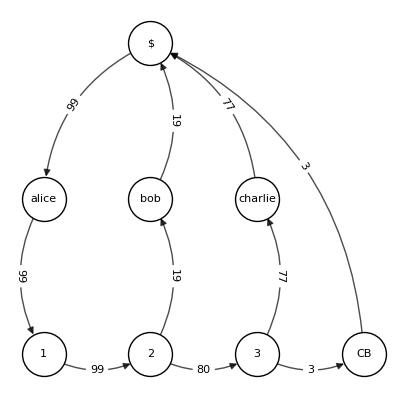

In [19]:
p_s_hat = max_flow_solver(p_s)

graph_draw(p_s_hat, pos=pos, connectionstyle="arc3, rad=0.3", node_size=1000)


The money node is balanced. Money from Alice's account or escrow can be distributed without remainders.

$3 + 77 + 19 = 99$

We complete the settlement to see the final result with a final distribution of funds. We use a standard state transition formula

$ g_s' = (g_s-\hat{p_s})^+ + (g_s-\hat{p_s})^{-\top} $

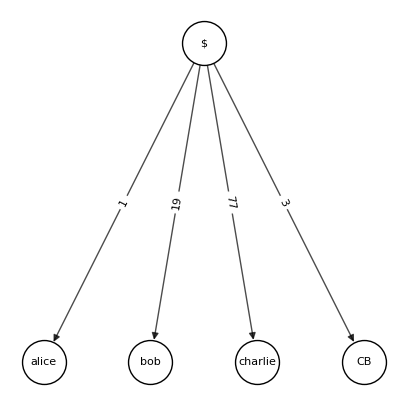

In [20]:
g_s_prime = +(g_s-p_s_hat) + ~(-(g_s-p_s_hat))

# Remove the discount ladder from the final state
for node in ladder:
    g_s_prime.remove_node(node)

# Reposition nodes for nicer presentation
pos = {'alice': (0,1),
       'bob': (2,1),
       'charlie': (4,1),
       'CB': (6,1),
       '$': (3,2)}

graph_draw(g_s_prime, pos=pos, connectionstyle="arc3, rad=0", node_size=1000)

The final result is as we would expect.

* Alice made an early payment and got her 1% discount. She saved 1 because she paid early.
* Bob got part of his receivables early at 2%.
* Charlie got his accounts receivable early at 3%.

Cash Back bucket holds a potential profit and rewards for participants in the future.

We have started with Alice having 100. The result is a redistribution of
Alice's funds. This cleared obligations unknown to the discount ladder in
the obligation network N and enabled Alice, Bob, and Charlie to achieve
their goals. In addition, we have a "Cash Back" bucket we can use to
incentivize liquidity providers even more.
